# Multi-objective BO: OPV light-intensity dependant JV fits with SIMsalabim (real data)
This notebook is a demonstration of how to fit light-intensity dependent JV curves with drift-diffusion models using the [SIMsalabim](https://github.com/kostergroup/SIMsalabim) package.

In [ ]:
# Import necessary libraries
import warnings, os, sys, shutil
# remove warnings from the output
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from scipy import constants
import torch, copy, uuid
import pySIMsalabim as sim
from pySIMsalabim.experiments.JV_steady_state import *
import ax, logging
from ax.utils.notebook.plotting import init_notebook_plotting, render
init_notebook_plotting() # for Jupyter notebooks

try:
    from optimpv import *
    from optimpv.optimizers.axBOtorch.axUtils import *
except Exception as e:
    sys.path.append('../..') # add the path to the optimpv module
    from optimpv import *
    from optimpv.optimizers.axBOtorch.axUtils import *

[INFO 01-20 10:54:26] ax.utils.notebook.plotting: Injecting Plotly library into cell. Do not overwrite or delete cell.
[INFO 01-20 10:54:26] ax.utils.notebook.plotting: Please see
    (https://ax.dev/tutorials/visualizations.html#Fix-for-plots-that-are-not-rendering)
    if visualizations are not rendering.


## Get the experimental data

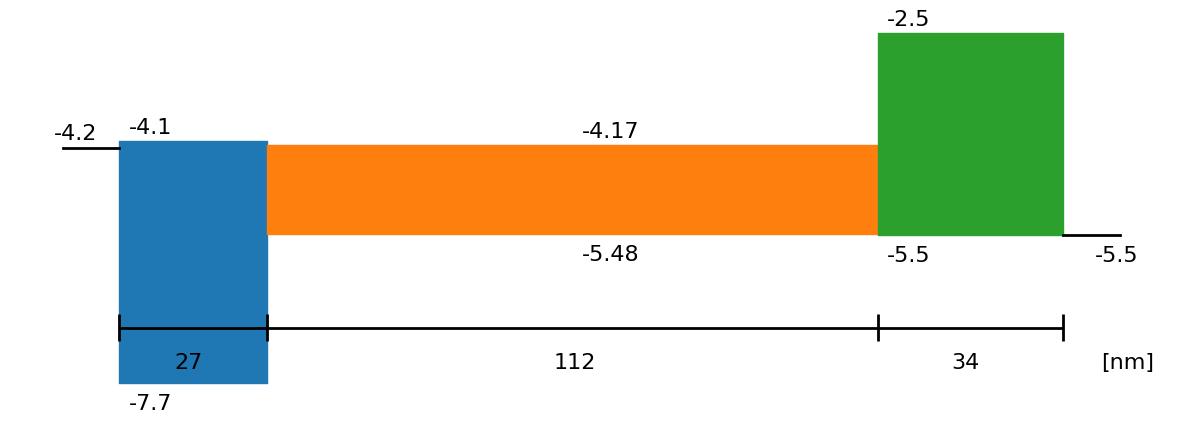

Gfracs = [1.  0.1 0.5]
Voc_1sun = 0.8613743287822753 V


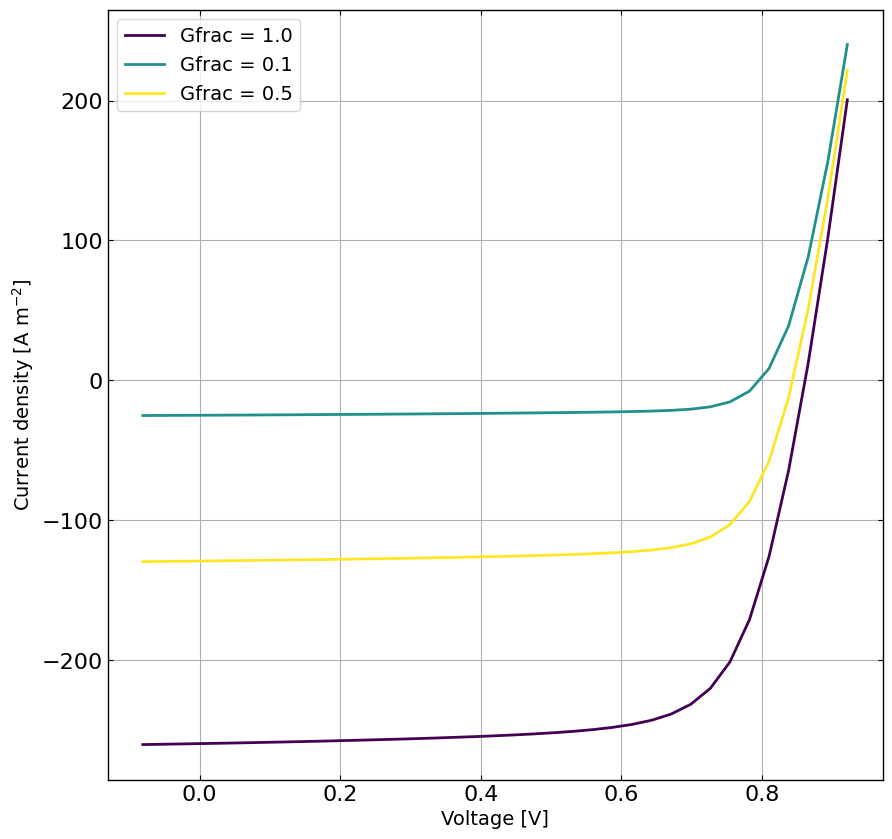

In [2]:
# Set the session path for the simulation and the input files
session_path = os.path.join(os.path.join(os.path.abspath('../'),'SIMsalabim','SimSS'))
input_path = os.path.join(os.path.join(os.path.join(os.path.abspath('../'),'Data','simsalabim_test_inputs','JVrealOPV')))
simulation_setup_filename = 'simulation_setup_PM6_L8BO.txt'
simulation_setup = os.path.join(session_path, simulation_setup_filename) 

# path to the layer files defined in the simulation_setup file
l1 = 'ZnO.txt'
l2 = 'PM6_L8BO.txt'
l3 = 'BM_HTL.txt'
l1 = os.path.join(input_path, l1 )
l2 = os.path.join(input_path, l2 )
l3 = os.path.join(input_path, l3 )

# copy this files to session_path
force_copy = True
if not os.path.exists(session_path):
    os.makedirs(session_path)
for file in [l1,l2,l3,simulation_setup_filename]:
    file = os.path.join(input_path, os.path.basename(file))
    if force_copy or not os.path.exists(os.path.join(session_path, os.path.basename(file))):
        shutil.copyfile(file, os.path.join(session_path, os.path.basename(file)))
    else:
        print('File already exists: ',file)

# Show the device structure
fig = sim.plot_band_diagram(simulation_setup, session_path)
dev_par, layers = sim.load_device_parameters(session_path, simulation_setup, run_mode = False)
SIMsalabim_params  = {}
for layer in layers:
    SIMsalabim_params[layer[1]] = sim.ReadParameterFile(os.path.join(session_path,layer[2]))
L_active_Layer = float(SIMsalabim_params['l2']['L'])

# Load the JV data
# Gfracs = [0.1,0.5,1.0] # Fractions of the generation rate to simulate (None if you want only one light intensity as define in the simulation_setup file)

# import JV data
df = pd.read_csv(os.path.join(input_path, 'JV_PM6_L8BO.dat'), sep=' ')
# X = vext,gfrac columns
X = df[['Vext','Gfrac']].values
y = df[['Jext']].values.reshape(-1)
# same order of the Gfrac as they appear in the data
Gfracs = pd.unique(df['Gfrac'])
# Gfracs = np.unique(df[['Gfrac']].values)
print(f'Gfracs = {Gfracs}')
X_1sun = df[['Vext','Gfrac']].values[df['Gfrac'] == 1.0]
y_1sun = df[['Jext']].values[df['Gfrac'] == 1.0].reshape(-1)
# get 1sun Jsc as it will help narrow down the range for Gehp
Jsc_1sun = np.interp(0.0, X_1sun[:,0], y_1sun)
minJ = np.min(y_1sun)
q = constants.value(u'elementary charge')
G_ehp_calc = abs(Jsc_1sun/(q*L_active_Layer))
G_ehp_max = abs(minJ/(q*L_active_Layer))
# get Voc
Voc_1sun = np.interp(0.0, y_1sun, X_1sun[:,0])
print(f'Voc_1sun = {Voc_1sun} V')
# Filter some data
Vmin = -0.1
Jmax = abs(Jsc_1sun)
idx = np.where((X[:,0] > Vmin) & (y < Jmax))
y = y[idx]
X = X[idx]

# get the data for each Gfrac with will be used in the different agents later
X1 = X[X[:,1] == Gfracs[0]]
y1 = y[X[:,1] == Gfracs[0]]
X2 = X[X[:,1] == Gfracs[1]]
y2 = y[X[:,1] == Gfracs[1]]
X3 = X[X[:,1] == Gfracs[2]]
y3 = y[X[:,1] == Gfracs[2]]


# plot the data for each Gfrac
plt.figure(figsize=(10,10))
viridis = plt.get_cmap('viridis', len(Gfracs))
for i, Gfrac in enumerate(Gfracs):
    plt.plot(X[X[:,1] == Gfrac][:,0], y[X[:,1] == Gfrac], '-', label = f'Gfrac = {Gfrac}', color = viridis(i))
plt.grid()
plt.xlabel('Voltage [V]')
plt.ylabel('Current density [A m$^{-2}$]')
plt.legend()
plt.show()

## Define the parameters for the simulation

In [3]:
params = [] # list of parameters to be optimized

mun = FitParam(name = 'l2.mu_n', value = 7e-8, bounds = [1e-9,1e-6], log_scale = True, value_type = 'float', fscale = None, rescale = False, display_name=r'$\mu_n$', unit='m$^2$ V$^{-1}$s$^{-1}$', axis_type = 'log', force_log = True)
params.append(mun)

mup = FitParam(name = 'l2.mu_p', value = 5e-8, bounds = [1e-9,1e-6], log_scale = True, value_type = 'float', fscale = None, rescale = False, display_name=r'$\mu_p$', unit=r'm$^2$ V$^{-1}$s$^{-1}$', axis_type = 'log', force_log = True)
params.append(mup)

bulk_tr = FitParam(name = 'l2.N_t_bulk', value = 1e20, bounds = [1e16,8e22], log_scale = True, value_type = 'float', fscale = None, rescale = False,  display_name=r'$N_{T}$', unit=r'm$^{-3}$', axis_type = 'log', force_log = True)
params.append(bulk_tr)

preLangevin = FitParam(name = 'l2.preLangevin', value = 1e-2, bounds = [1e-3,1], log_scale = True, value_type = 'float', fscale = None, rescale = False, display_name=r'$\gamma_{pre}$', unit=r'', axis_type = 'log', force_log = True)
params.append(preLangevin)

R_series = FitParam(name = 'R_series', value = 1e-4, bounds = [1e-6,1e-2], log_scale = True, value_type = 'float', fscale = None, rescale = False,  display_name=r'$R_{series}$', unit=r'$\Omega$ m$^2$', axis_type = 'log', force_log = False)
params.append(R_series)

R_shunt = FitParam(name = 'R_shunt', value = 1e1, bounds = [1e-2,1e2], log_scale = True, value_type = 'float', fscale = None, rescale = False,  display_name=r'$R_{shunt}$', unit=r'$\Omega$ m$^2$', axis_type = 'log', force_log = False)
params.append(R_shunt)

G_ehp = FitParam(name = 'l2.G_ehp', value = G_ehp_calc, bounds = [G_ehp_calc*0.95,G_ehp_max*1.05], log_scale = False, value_type = 'float', fscale = None, rescale = False,  display_name=r'$G_{ehp}$', unit=r'm$^{-3}$ s$^{-1}$', axis_type = 'linear', force_log = False)
params.append(G_ehp)

# save the original parameters for later
params_orig = copy.deepcopy(params)
num_free_params = len([p for p in params if p.type != 'fixed'])

## Run the optimization

In [4]:
# Define the Agent and the target metric/loss function
from optimpv.models.DDfits.JVAgent import JVAgent
metric = 'nrmse' # can be 'nrmse', 'mse', 'mae'
loss = 'linear' # can be 'linear', 'huber', 'soft_l1'
threshold = 0.05 # need this to get a reference point for the hypervolume calculation
jv_main = JVAgent(params, X, y, session_path, simulation_setup, parallel = True, max_jobs = 3, metric = metric, loss = loss) # agent with ALL the light intensities, not necessary for the MOO but useful later
# The agents below need to add a different name for each agent otherwise they will overwrite each other in the jv.run_Ax output dictionary
jv1 = JVAgent(params, X1, y1, session_path, simulation_setup, parallel = True, max_jobs = 1, metric = metric, loss = loss, threshold=threshold,name='Gfrac1') # agent with Gfrac 1 
jv2 = JVAgent(params, X2, y2, session_path, simulation_setup, parallel = True, max_jobs = 1, metric = metric, loss = loss, threshold=threshold,name='Gfrac2') # agent with Gfrac 2
jv3 = JVAgent(params, X3, y3, session_path, simulation_setup, parallel = True, max_jobs = 1, metric = metric, loss = loss, threshold=threshold,name='Gfrac3') # agent with Gfrac 3


In [5]:
from optimpv.optimizers.axBOtorch.axBOtorchOptimizer import axBOtorchOptimizer
from optimpv.optimizers.axBOtorch.axUtils import get_VMLC_default_model_kwargs_list

optimizer = axBOtorchOptimizer(params = params, agents = [jv1,jv2,jv3], models = ['CENTER','SOBOL','BOTORCH_MODULAR'],n_batches = [1,1,60], batch_size = [1,10,2], max_parallelism = 100, model_kwargs_list = get_VMLC_default_model_kwargs_list(num_free_params,use_CENTER=True,is_MOO=True))


In [6]:
optimizer.optimize() # run the optimization with ax

[INFO 01-20 10:54:27] optimpv.axBOtorchOptimizer: Trial 0 with parameters: {'l2.mu_n': -7.5, 'l2.mu_p': -7.5, 'l2.N_t_bulk': 19.451544993495972, 'l2.preLangevin': -1.5, 'R_series': 0.0001, 'R_shunt': 1.0, 'l2.G_ehp': 1.4669272681272731e+28}
[INFO 01-20 10:54:28] optimpv.axBOtorchOptimizer: Trial 0 completed with results: {'Gfrac1_JV_nrmse_linear': np.float64(0.13334896922864783), 'Gfrac2_JV_nrmse_linear': np.float64(0.08254634225523515), 'Gfrac3_JV_nrmse_linear': np.float64(0.11049013404965334)}
[INFO 01-20 10:54:28] optimpv.axBOtorchOptimizer: Trial 1 with parameters: {'l2.mu_n': -7.100285153836012, 'l2.mu_p': -8.561031312681735, 'l2.N_t_bulk': 16.146061026446894, 'l2.preLangevin': -2.9701101751998067, 'R_series': 0.0004786131197769525, 'R_shunt': 0.10838000360254822, 'l2.G_ehp': 1.5045244836223446e+28}
[INFO 01-20 10:54:28] optimpv.axBOtorchOptimizer: Trial 2 with parameters: {'l2.mu_n': -8.040233619511127, 'l2.mu_p': -7.482117449864745, 'l2.N_t_bulk': 22.81782760341674, 'l2.preLange

In [7]:
# get the best parameters and update the params list in the optimizer and the agent
ax_client = optimizer.ax_client # get the ax client
optimizer.update_params_with_best_balance() # update the params list in the optimizer with the best parameters
jv_main.params = optimizer.params # update the params list in the agent with the best parameters

# print the best parameters
print('Best parameters:')
for p in optimizer.params:
    print(p.name, 'fitted value:', p.value)
    
print('\nSimSS command line:')
print(jv_main.get_SIMsalabim_clean_cmd(jv_main.params)) # print the simss command line with the best parameters


Best parameters:
l2.mu_n fitted value: 3.238961904466114e-08
l2.mu_p fitted value: 1.814838494350394e-08
l2.N_t_bulk fitted value: 8.441128577616348e+17
l2.preLangevin fitted value: 0.0016157700608006532
R_series fitted value: 5.397964167467749e-05
R_shunt fitted value: 70.57835445866161
l2.G_ehp fitted value: 1.4286430730617906e+28

SimSS command line:
./simss -l2.mu_n 3.238961904466114e-08 -l2.mu_p 1.814838494350394e-08 -l2.N_t_bulk 8.441128577616348e+17 -l2.preLangevin 0.0016157700608006532 -R_series 5.397964167467749e-05 -R_shunt 70.57835445866161 -l2.G_ehp 1.4286430730617906e+28


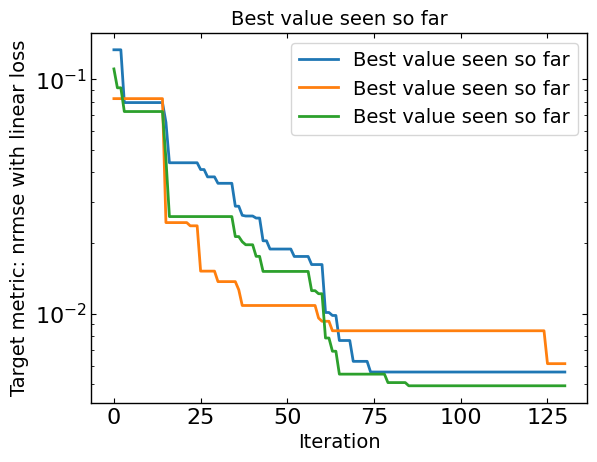

In [8]:
# Plot optimization results
data = ax_client.summarize()
all_metrics = optimizer.all_metrics
plt.figure()
plt.plot(np.minimum.accumulate(data[all_metrics]), label="Best value seen so far")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Target metric: " + metric + " with " + loss + " loss")
plt.legend()
plt.title("Best value seen so far")

plt.show()

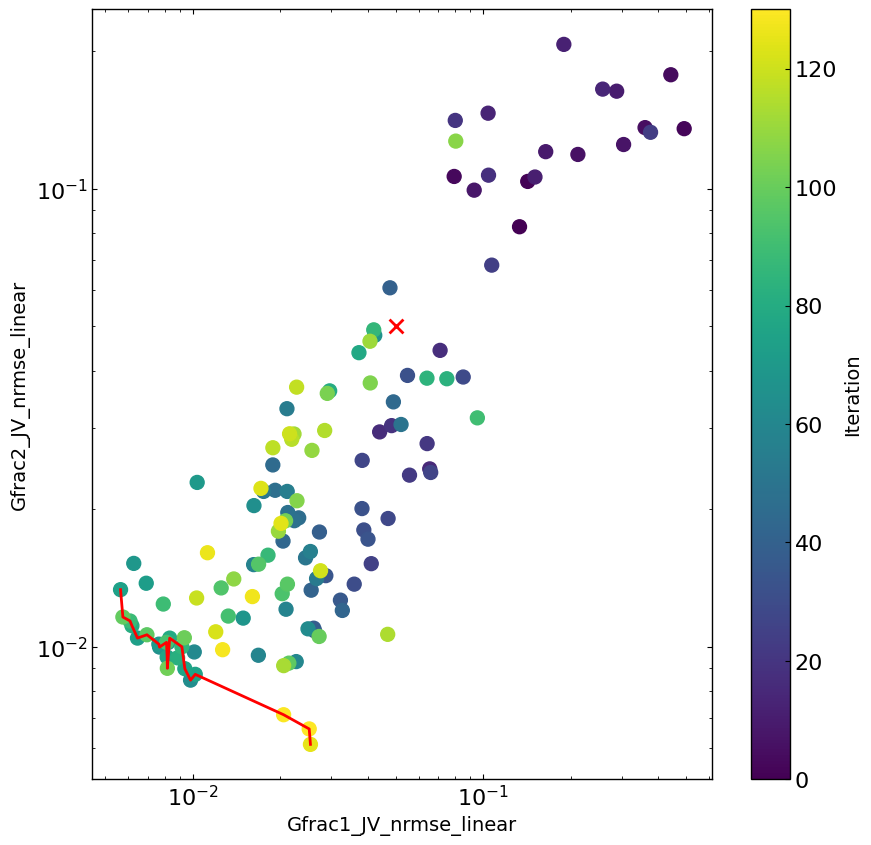

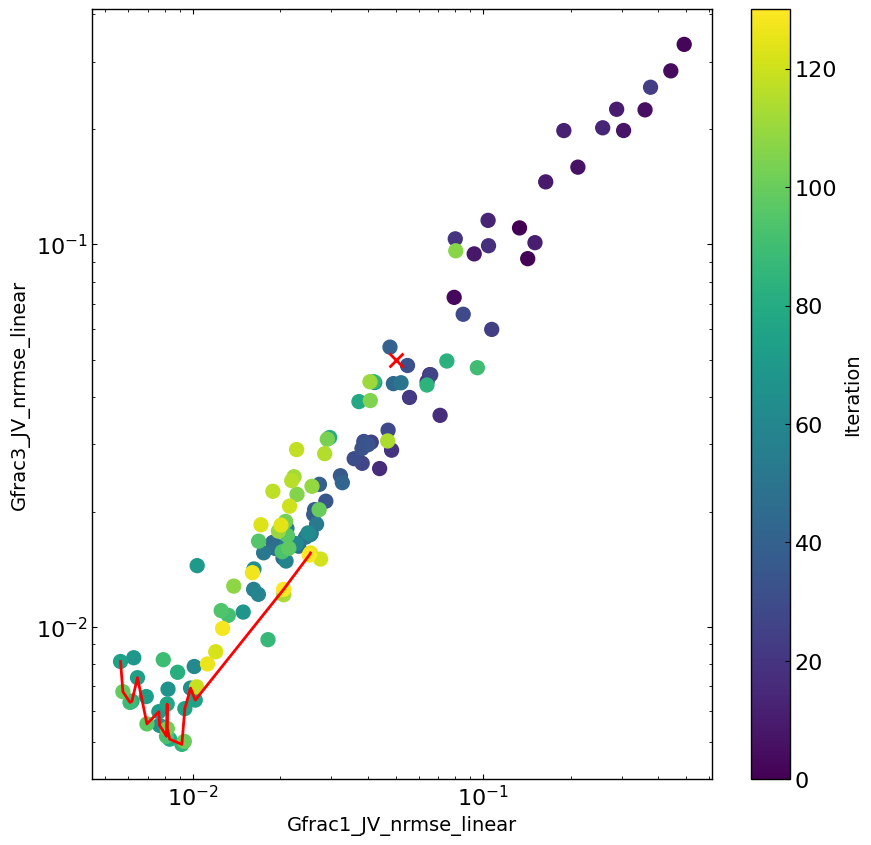

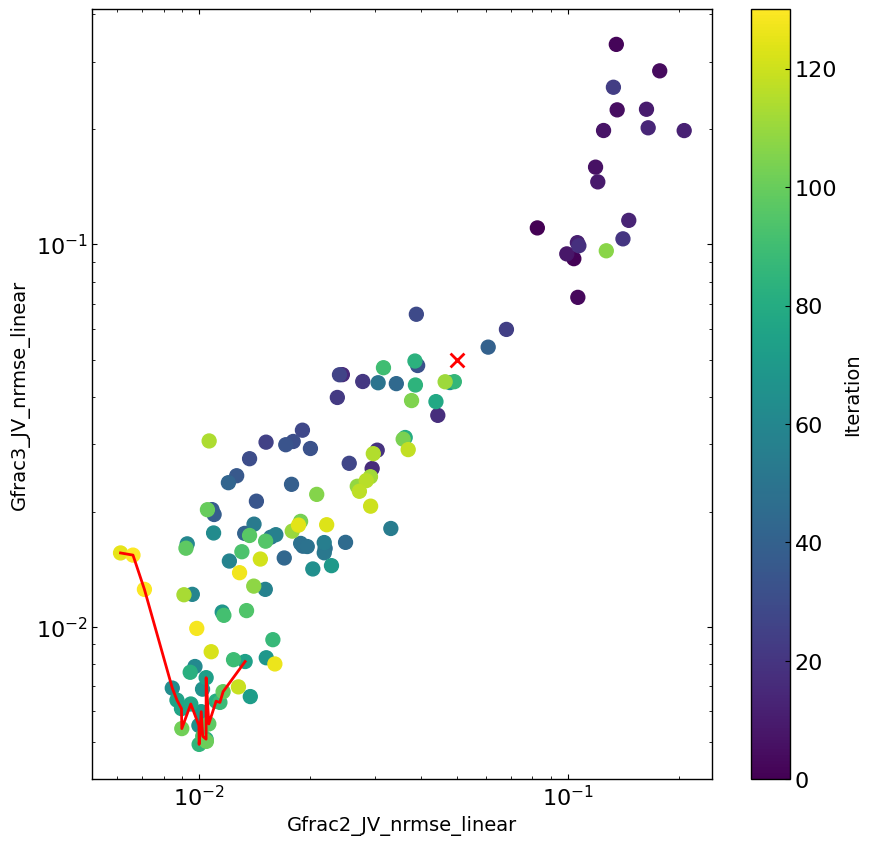

In [9]:
import matplotlib
# import itertools
from itertools import combinations
comb = list(combinations(optimizer.all_metrics, 2))
threshold_list = []
for i in range(len(optimizer.agents)):
    for j in range(len(optimizer.agents[i].threshold)):
        threshold_list.append(optimizer.agents[i].threshold[j])
threshold_comb = list(combinations(threshold_list, 2))
pareto = ax_client.get_pareto_frontier(use_model_predictions=False)

cm = matplotlib.colormaps.get_cmap('viridis')
df = get_df_from_ax(params, optimizer)
# create pareto df
dum_dic = {}
for eto in pareto:
    for metr in optimizer.all_metrics:
        if metr not in dum_dic.keys():
            dum_dic[metr] = []
        dum_dic[metr].append(eto[1][metr][0])
df_pareto = pd.DataFrame(dum_dic)

for c,t_c in zip(comb,threshold_comb):
    plt.figure(figsize=(10, 10))
    plt.scatter(df[c[0]],df[c[1]],c=df.index, cmap=cm, marker='o', s=100) # plot the points with color according to the iteration
    cbar = plt.colorbar()
    cbar.set_label('Iteration')
    sorted_df = df_pareto.sort_values(by=c[0])
    plt.plot(sorted_df[c[0]],sorted_df[c[1]],'r') 
    plt.scatter(t_c[0],t_c[1],c='r', marker='x', s=100) # plot the threshold
    plt.xlabel(c[0])
    plt.ylabel(c[1])
    plt.xscale('log')
    plt.yscale('log')
    
    
    plt.show()


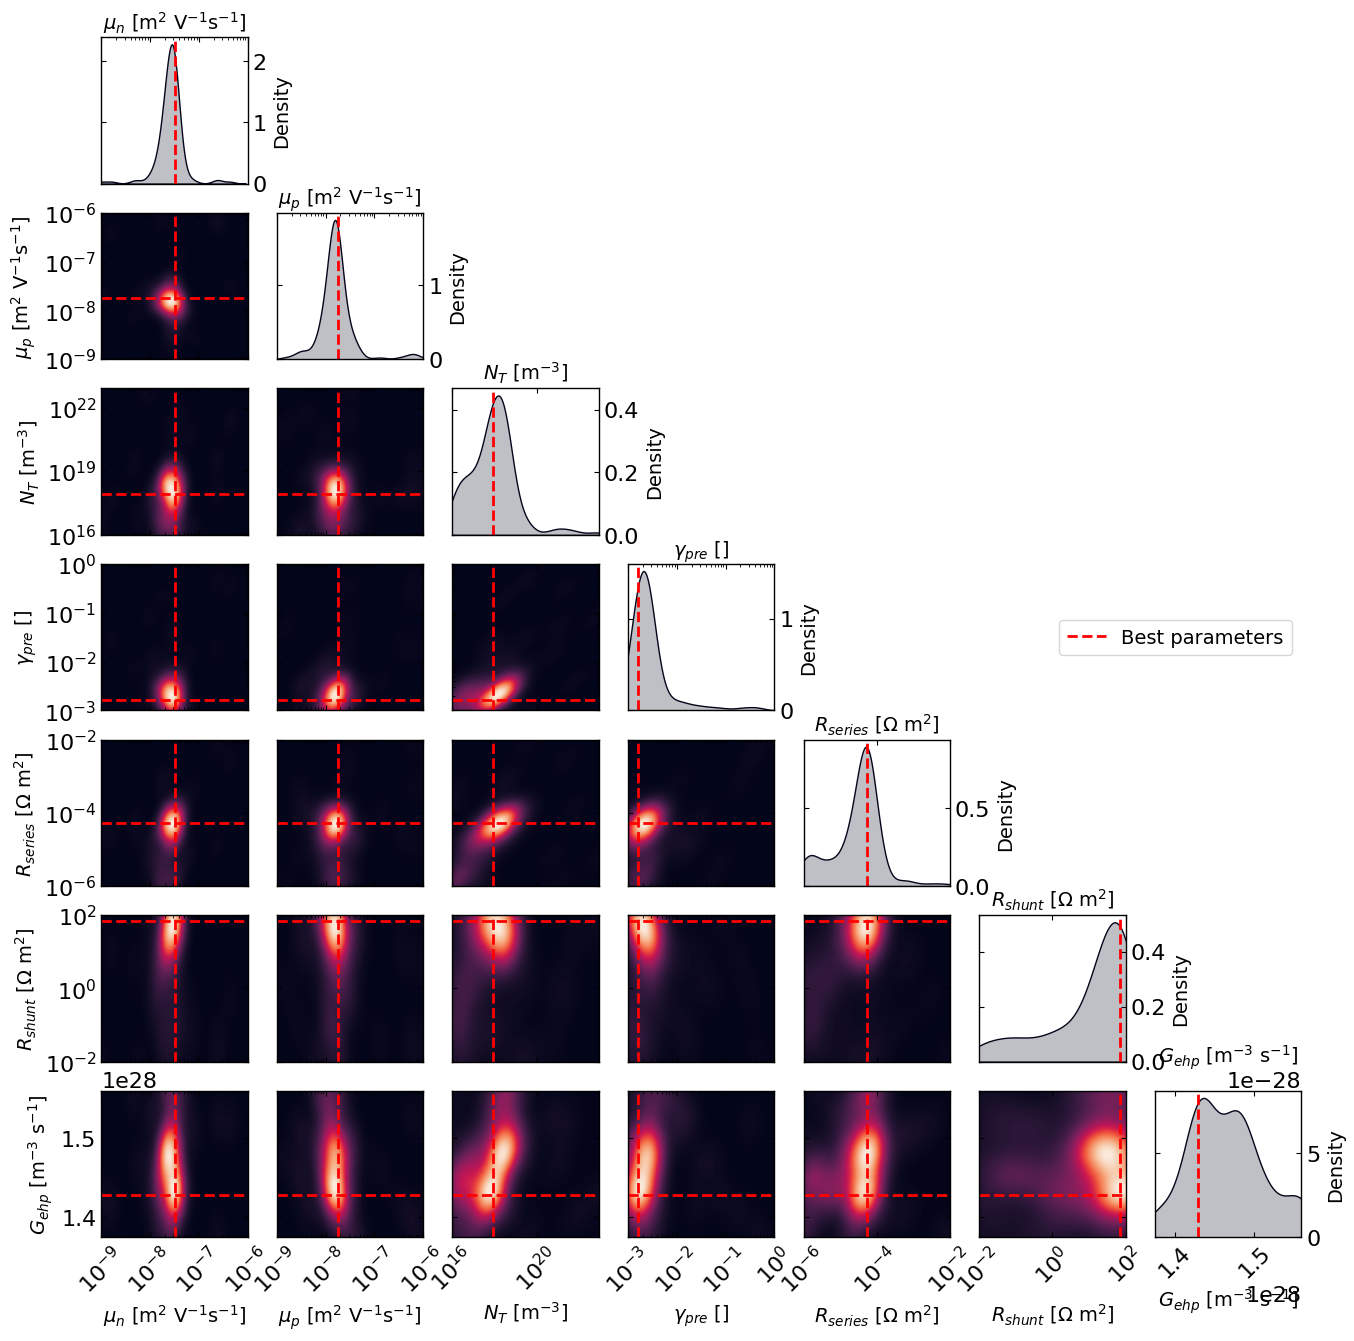

In [10]:
# Plot the density of the exploration of the parameters
# this gives a nice visualization of where the optimizer focused its exploration and may show some correlation between the parameters
plot_dens = True
if plot_dens:
    from optimpv.posterior.exploration_density import *
    best_parameters = {}
    for p in optimizer.params:
        best_parameters[p.name] = p.value

    fig_dens, ax_dens = plot_density_exploration(params, optimizer = optimizer, best_parameters = best_parameters, optimizer_type = 'ax')


Best combined target metric: 0.005653415170981986


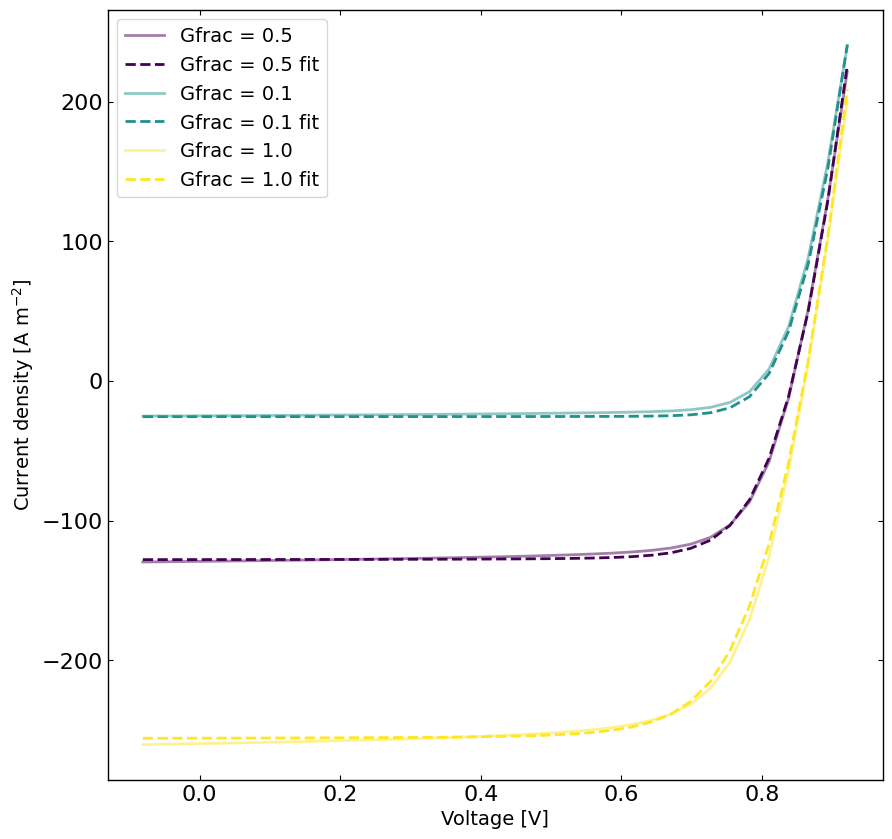

In [11]:
# rerun the simulation with the best parameters
yfit = jv_main.run(parameters={}) # run the simulation with the best parameters
res_dic = jv_main.run_Ax(parameters={})
keys = list(res_dic.keys())
print('Best combined target metric:', res_dic[keys[0]])
viridis = plt.get_cmap('viridis', len(Gfracs))
plt.figure(figsize=(10,10))
linewidth = 2
for idx, Gfrac in enumerate(Gfracs[::-1]):
    plt.plot(X[X[:,1]==Gfrac,0],y[X[:,1]==Gfrac],label='Gfrac = '+str(Gfrac),color=viridis(idx),alpha=0.5,linewidth=linewidth)
    plt.plot(X[X[:,1]==Gfrac,0],yfit[X[:,1]==Gfrac],label='Gfrac = '+str(Gfrac)+' fit',linestyle='--',color=viridis(idx),linewidth=linewidth)
plt.xlabel('Voltage [V]')
plt.ylabel('Current density [A m$^{-2}$]')
plt.legend()
plt.show()

In [12]:
# Clean up the output files (comment out if you want to keep the output files)
sim.clean_all_output(session_path)
sim.delete_folders('tmp',session_path)
# uncomment the following lines to delete specific files
sim.clean_up_output('ZnO',session_path)
sim.clean_up_output('PM6_L8BO',session_path)
sim.clean_up_output('BM_HTL',session_path)
sim.clean_up_output('simulation_setup_PM6_L8BO',session_path)